In [1]:
pip install yfinance pandas

In [2]:
import yfinance as yf

ticker = yf.Ticker("GC=F")

df = ticker.history(start="2025-09-02", end="2026-09-02", interval="1d", auto_adjust=False)

df = df.drop(columns=['Dividends', 'Stock Splits'], errors='ignore')

df_display = df.reset_index()

display(df_display)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2025-09-02 00:00:00-04:00,3485.699951,3559.199951,3485.699951,3549.399902,3549.399902,658
1,2025-09-03 00:00:00-04:00,3554.800049,3593.699951,3553.199951,3593.199951,3593.199951,72
2,2025-09-04 00:00:00-04:00,3549.899902,3573.600098,3549.899902,3565.800049,3565.800049,237
3,2025-09-05 00:00:00-04:00,3567.800049,3613.199951,3567.800049,3613.199951,3613.199951,925
4,2025-09-08 00:00:00-04:00,3594.500000,3641.000000,3590.000000,3638.100098,3638.100098,97
...,...,...,...,...,...,...,...
247,2026-08-26 00:00:00-04:00,4615.299805,4615.299805,4598.200195,4598.200195,4598.200195,1051
248,2026-08-27 00:00:00-04:00,4609.700195,4609.700195,4609.700195,4609.700195,4609.700195,5558
249,2026-08-28 00:00:00-04:00,4599.299805,4625.500000,4451.799805,4478.100098,4478.100098,1758
250,2026-08-31 00:00:00-04:00,4430.000000,4466.899902,4410.899902,4431.100098,4431.100098,360


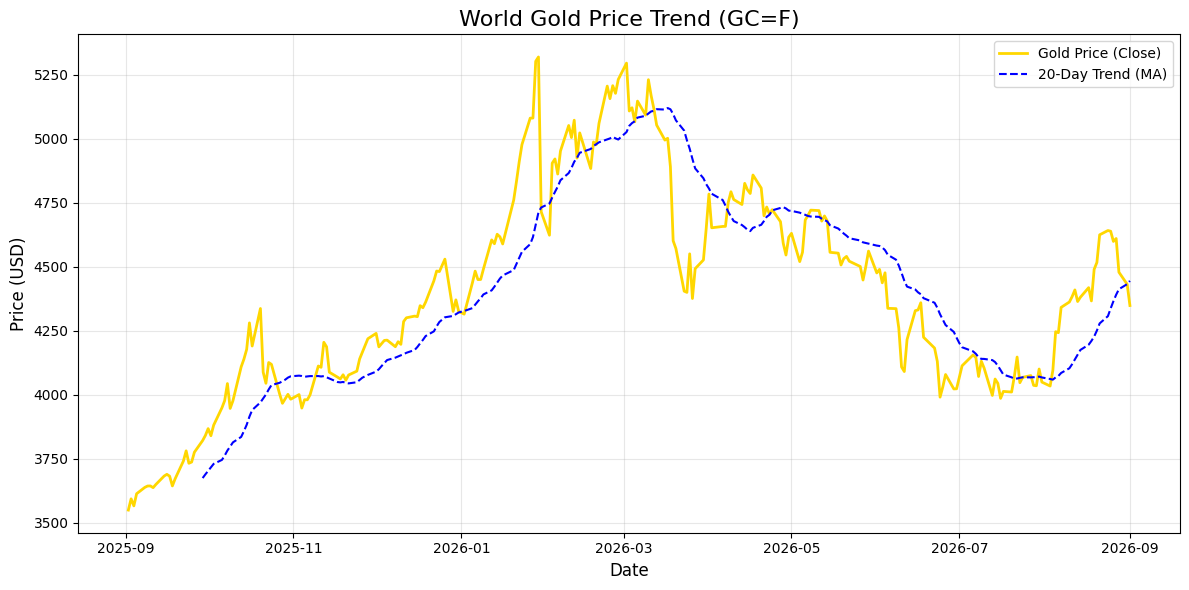

In [3]:
import matplotlib.pyplot as plt

df['MA20'] = df['Close'].rolling(window=20).mean()

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Gold Price (Close)', color='gold', linewidth=2)
plt.plot(df.index, df['MA20'], label='20-Day Trend (MA)', color='blue', linestyle='--')

plt.title('World Gold Price Trend (GC=F)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries):
    print('Augmented Dickey-Fuller test results:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

    if dftest[1] <= 0.05:
        print("\nKết luận: Chuỗi có tính dừng (Bác bỏ H0)")
    else:
        print("\nConclusion: The series is non-stationary (Accept H0). You need to take the difference.")

import pandas as pd
adf_test(df['Close'].dropna())

Augmented Dickey-Fuller test results:
Test Statistic                  -2.293079
p-value                          0.174210
#Lags Used                       0.000000
Number of Observations Used    251.000000
Critical Value (1%)             -3.456674
Critical Value (5%)             -2.873125
Critical Value (10%)            -2.572944
dtype: float64

Conclusion: The series is non-stationary (Accept H0). You need to take the difference.


--- ADF test for the first-differenced series ---
Augmented Dickey-Fuller test results:
Test Statistic                -1.234737e+01
p-value                        5.930535e-23
#Lags Used                     1.000000e+00
Number of Observations Used    2.490000e+02
Critical Value (1%)           -3.456888e+00
Critical Value (5%)           -2.873219e+00
Critical Value (10%)          -2.572994e+00
dtype: float64

Kết luận: Chuỗi có tính dừng (Bác bỏ H0)


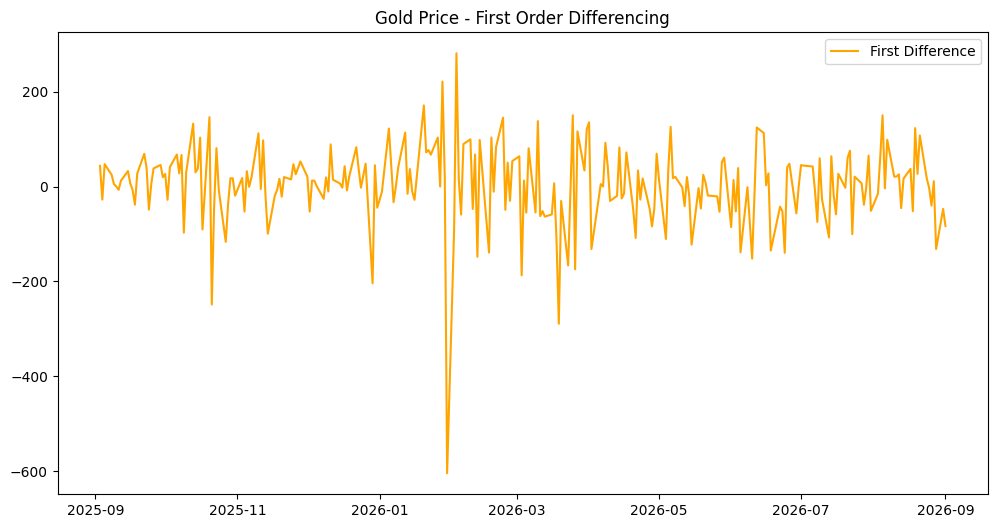

In [5]:
df['Close_diff'] = df['Close'].diff()

print("--- ADF test for the first-differenced series ---")
adf_test(df['Close_diff'].dropna())

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df['Close_diff'], label='First Difference', color='orange')
plt.title('Gold Price - First Order Differencing')
plt.legend()
plt.show()

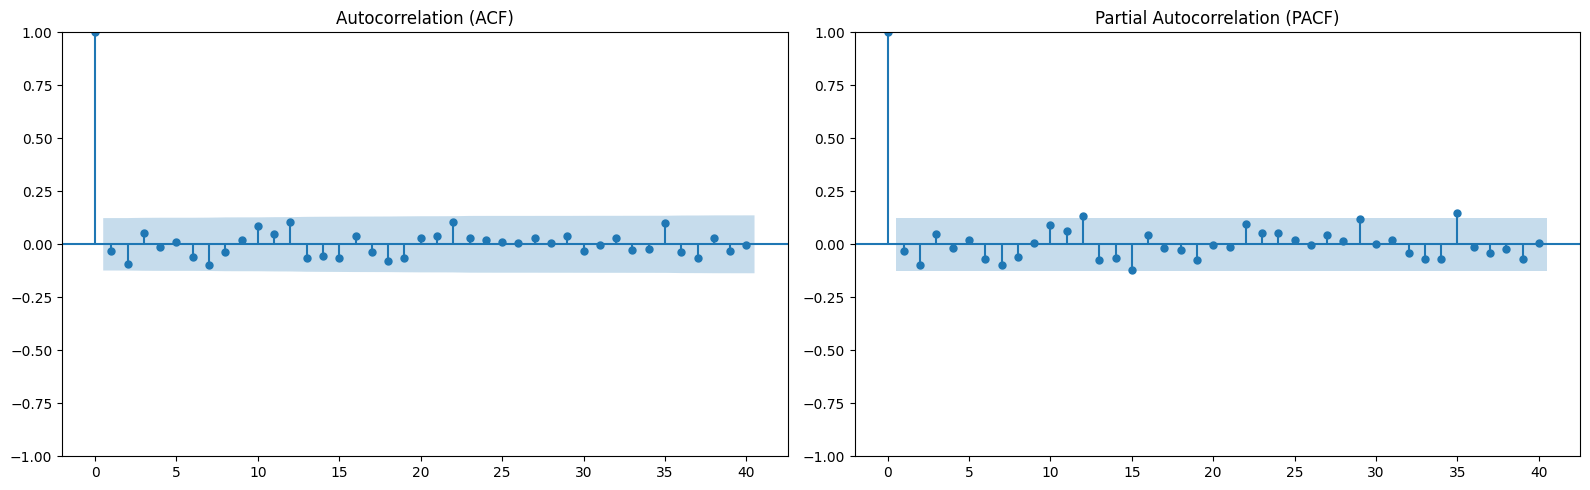

In [6]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(df['Close_diff'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

plot_pacf(df['Close_diff'].dropna(), lags=40, ax=axes[1], method='yw')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

In [7]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

def evaluate_arima_models(dataset, p_values, d_value, q_values):
    best_score, best_cfg = float("inf"), None
    results = []

    for p in p_values:
        for q in q_values:
            order = (p, d_value, q)
            try:
                model = ARIMA(dataset, order=order)
                model_fit = model.fit()
                aic = model_fit.aic
                results.append((order, aic))
                if aic < best_score:
                    best_score, best_cfg = aic, order
                print(f'ARIMA{order} - AIC: {aic:.3f}')
            except:
                continue

    print(f'\n---> Best Model: ARIMA{best_cfg} with AIC = {best_score:.3f}')
    return best_cfg, results

p_range = range(0, 4)
d_fixed = 1
q_range = range(0, 4)

best_order, all_results = evaluate_arima_models(df['Close'], p_range, d_fixed, q_range)

ARIMA(0, 1, 0) - AIC: 2939.395
ARIMA(0, 1, 1) - AIC: 2941.156
ARIMA(0, 1, 2) - AIC: 2941.027
ARIMA(0, 1, 3) - AIC: 2942.167
ARIMA(1, 1, 0) - AIC: 2941.201
ARIMA(1, 1, 1) - AIC: 2942.350
ARIMA(1, 1, 2) - AIC: 2942.215
ARIMA(1, 1, 3) - AIC: 2944.138
ARIMA(2, 1, 0) - AIC: 2940.990
ARIMA(2, 1, 1) - AIC: 2942.153
ARIMA(2, 1, 2) - AIC: 2944.153
ARIMA(2, 1, 3) - AIC: 2942.643
ARIMA(3, 1, 0) - AIC: 2942.375
ARIMA(3, 1, 1) - AIC: 2944.153
ARIMA(3, 1, 2) - AIC: 2946.027
ARIMA(3, 1, 3) - AIC: 2940.073

---> Best Model: ARIMA(0, 1, 0) with AIC = 2939.395


In [8]:
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Huấn luyện mô hình ARIMA(3,1,3)
model = ARIMA(df['Close'], order=(3, 1, 3))
model_fit = model.fit()

# 2. Dự báo 10 ngày tiếp theo
forecast_steps = 10
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast_series = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Tạo chỉ mục ngày cho dự báo
last_date = df.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps)
forecast_series.index = forecast_dates
conf_int.index = forecast_dates

# 3. Hiển thị kết quả
print("Dự báo giá vàng trong 10 ngày tới:")
print(forecast_series)


Dự báo giá vàng trong 10 ngày tới:
2026-09-02 00:00:00-04:00    4351.793814
2026-09-03 00:00:00-04:00    4319.290519
2026-09-04 00:00:00-04:00    4298.608630
2026-09-05 00:00:00-04:00    4293.597163
2026-09-06 00:00:00-04:00    4322.357401
2026-09-07 00:00:00-04:00    4340.656475
2026-09-08 00:00:00-04:00    4346.610278
2026-09-09 00:00:00-04:00    4321.140185
2026-09-10 00:00:00-04:00    4305.035023
2026-09-11 00:00:00-04:00    4298.369012
Freq: D, Name: predicted_mean, dtype: float64


In [9]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Sử dụng đúng tên biến 'model_fit' đã được định nghĩa ở cell trước
predictions = model_fit.predict(start=1, end=len(df)-1)
actuals = df['Close'][1:]

rmse = np.sqrt(mean_squared_error(actuals, predictions))

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

mape = mean_absolute_percentage_error(actuals, predictions)

print(f'Kết quả đánh giá mô hình ARIMA(3,1,3):')
print(f'- RMSE: {rmse:.4f}')
print(f'- MAPE: {mape:.4f}%')

Kết quả đánh giá mô hình ARIMA(3,1,3):
- RMSE: 82.1149
- MAPE: 1.2860%


In [10]:
residuals = model_fit.resid

In [11]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

data_lstm = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data_lstm)

print(f"Hình dạng dữ liệu sau chuẩn hóa: {scaled_data.shape}")
print("5 giá trị đầu tiên sau khi chuẩn hóa:")
print(scaled_data[:5])

Hình dạng dữ liệu sau chuẩn hóa: (252, 1)
5 giá trị đầu tiên sau khi chuẩn hóa:
[[0.        ]
 [0.02475978]
 [0.00927086]
 [0.0360656 ]
 [0.05014143]]


In [12]:
look_back = 20
def create_res_dataset(res_data, look_back):
    X, y = [], []
    for i in range(len(res_data) - look_back):
        X.append(res_data[i:(i + look_back)])
        y.append(res_data[i + look_back])
    return np.array(X), np.array(y)

In [13]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Lấy phần dư từ mô hình ARIMA (bỏ giá trị đầu tiên do differencing)
# Chúng ta sử dụng biến 'residuals' đã được tạo từ model_fit.resid trước đó
res_data = residuals.values[1:].reshape(-1, 1)

# 2. Khởi tạo và thực hiện chuẩn hóa trong khoảng [-1, 1]
scaler_res = MinMaxScaler(feature_range=(-1, 1))
scaled_res = scaler_res.fit_transform(res_data)

print(f"Hình dạng dữ liệu sai số sau chuẩn hóa: {scaled_res.shape}")
print("5 giá trị sai số đầu tiên sau khi chuẩn hóa:")
print(scaled_res[:5])

# Lưu lại scaler để sau này nghịch đảo kết quả dự báo
# Biến scaled_res này sẽ được dùng để tạo dataset cho LSTM

Hình dạng dữ liệu sai số sau chuẩn hóa: (251, 1)
5 giá trị sai số đầu tiên sau khi chuẩn hóa:
[[0.48705869]
 [0.32388967]
 [0.49063018]
 [0.43947994]
 [0.39231516]]


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

# 1. Tạo dataset X_res và y_res từ dữ liệu sai số đã chuẩn hóa
X_res, y_res = create_res_dataset(scaled_res, look_back)

# 2. Khởi tạo mô hình LSTM
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

# 3. Huấn luyện mô hình
lstm_model.fit(X_res, y_res, epochs=30, batch_size=16, verbose=0)

print("Mô hình LSTM đã được huấn luyện thành công trên phần dư (residuals).")

Mô hình LSTM đã được huấn luyện thành công trên phần dư (residuals).


In [17]:
last_res_window = scaled_res[-look_back:].reshape(1, look_back, 1)
lstm_res_forecast = []

# Sử dụng forecast_steps đã định nghĩa ở các cell trước (10 ngày)
current_window = last_res_window
for _ in range(forecast_steps):
    next_res = lstm_model.predict(current_window, verbose=0)
    lstm_res_forecast.append(next_res[0, 0])
    # Cập nhật cửa sổ dự báo
    next_res_reshaped = next_res.reshape(1, 1, 1)
    current_window = np.append(current_window[:, 1:, :], next_res_reshaped, axis=1)

print("Dự báo sai số (phần dư) từ LSTM hoàn tất.")

Dự báo sai số (phần dư) từ LSTM hoàn tất.


In [18]:
# 1. Nghịch đảo chuẩn hóa sai số từ LSTM về đơn vị USD
lstm_error_usd = scaler_res.inverse_transform(np.array(lstm_res_forecast).reshape(-1, 1)).flatten()

# 2. Cộng dự báo ARIMA (tuyến tính) và sai số LSTM (phi tuyến)
# forecast_series đã được định nghĩa ở cell bn1lsiowJ4l-
final_forecast = forecast_series.values + lstm_error_usd

print(f"--- DỰ BÁO HYBRID GIÁ VÀNG TRONG {forecast_steps} NGÀY TỚI ---")
for i, price in enumerate(final_forecast):
    print(f"Ngày {i+1} ({forecast_series.index[i].date()}): {price:.2f} USD")

--- DỰ BÁO HYBRID GIÁ VÀNG TRONG 10 NGÀY TỚI ---
Ngày 1 (2026-09-02): 4357.51 USD
Ngày 2 (2026-09-03): 4323.33 USD
Ngày 3 (2026-09-04): 4301.24 USD
Ngày 4 (2026-09-05): 4294.56 USD
Ngày 5 (2026-09-06): 4322.12 USD
Ngày 6 (2026-09-07): 4339.61 USD
Ngày 7 (2026-09-08): 4345.09 USD
Ngày 8 (2026-09-09): 4319.63 USD
Ngày 9 (2026-09-10): 4303.41 USD
Ngày 10 (2026-09-11): 4296.63 USD


In [19]:
# 1. Kiểm tra kích thước dữ liệu (sử dụng biến df đã tải ở các cell trước)
rows, cols = df.shape
print(f"Tổng số dòng dữ liệu: {rows}")
print(f"Tổng số cột dữ liệu: {cols}")
print("-" * 30)

# 2. Chia bộ huấn luyện (Train) và bộ thử nghiệm (Test) dựa trên cột 'Close'
# Lấy giá trị Close dưới dạng mảng
close_prices = df['Close'].values

train_size = int(len(close_prices) * 0.8)
train_data = close_prices[:train_size]
test_data = close_prices[train_size:]

print(f"Số lượng mẫu huấn luyện (80%): {len(train_data)}")
print(f"Số lượng mẫu thử nghiệm (20%): {len(test_data)}")

Tổng số dòng dữ liệu: 252
Tổng số cột dữ liệu: 8
------------------------------
Số lượng mẫu huấn luyện (80%): 201
Số lượng mẫu thử nghiệm (20%): 51


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 0.0924 - val_loss: 0.0343
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0475 - val_loss: 0.0280
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0493 - val_loss: 0.0220
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0485 - val_loss: 0.0221
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0486 - val_loss: 0.0219
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0466 - val_loss: 0.0221
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0467 - val_loss: 0.0226
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0469 - val_loss: 0.0217
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0472 - val_loss: 0.0216
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0476 - val_loss: 0.0226
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0473 - val_loss: 0.0215
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0

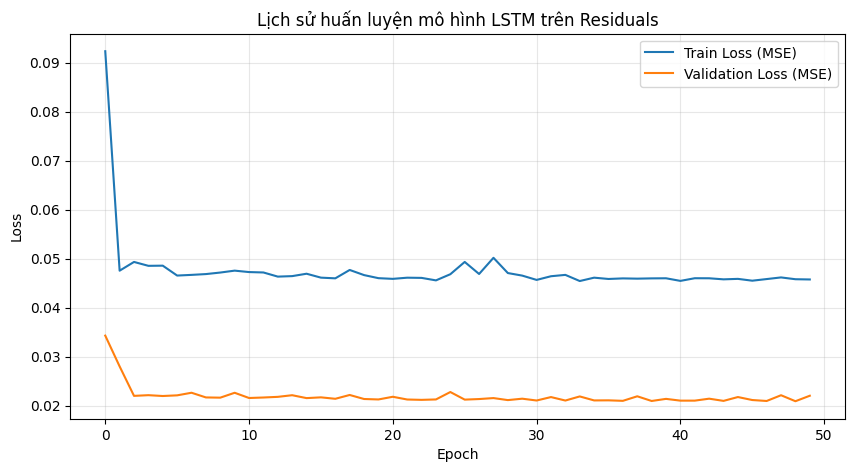

In [20]:
from sklearn.model_selection import train_test_split

# 1. Chia dữ liệu residuals thành bộ train và validation để lấy loss/val_loss
X_train_res, X_val_res, y_train_res, y_val_res = train_test_split(X_res, y_res, test_size=0.2, shuffle=False)

# 2. Định nghĩa lại và huấn luyện mô hình
# (Sử dụng lại cấu hình đã thiết lập trước đó)
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(look_back, 1)),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

# Huấn luyện và lưu lịch sử
history = lstm_model.fit(
    X_train_res, y_train_res,
    epochs=50,
    batch_size=16,
    validation_data=(X_val_res, y_val_res),
    verbose=1
)

# 3. Hiển thị Loss và Val_Loss cuối cùng
final_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
print(f"\n--- KẾT QUẢ HUẤN LUYỆN ---")
print(f"Loss cuối cùng (Train): {final_loss:.6f}")
print(f"Loss cuối cùng (Validation): {final_val_loss:.6f}")

# 4. Vẽ biểu đồ Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Lịch sử huấn luyện mô hình LSTM trên Residuals')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# 1. Chuẩn bị dữ liệu (Sử dụng data_lstm thay cho data)
train_size = int(len(data_lstm) * 0.8)
train, test = data_lstm[0:train_size], data_lstm[train_size:]
test_length = len(test)

# 2. Dự báo bằng ARIMA trên tập Test
history = [x for x in train.flatten()]
arima_test_forecast = []

for t in range(test_length):
    model = ARIMA(history, order=(3,1,3)) # Sử dụng order (3,1,3) như yêu cầu ban đầu
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    arima_test_forecast.append(yhat)
    history.append(test[t][0]) # Walk-forward validation

arima_test_forecast = np.array(arima_test_forecast)

# 3. Tính toán Residuals và dự báo bằng LSTM
test_residuals = test.flatten() - arima_test_forecast

# Chuẩn hóa residuals bằng scaler_res đã fit ở các ô trước
scaled_test_res = scaler_res.transform(test_residuals.reshape(-1, 1))

# Dự báo LSTM cho từng bước trong tập test
lstm_test_res_forecast = []
for i in range(len(scaled_test_res)):
    if i + train_size < look_back:
        continue
    # Lấy window từ phần dư đã chuẩn hóa trước đó
    window = scaled_res[train_size + i - look_back : train_size + i].reshape(1, look_back, 1)
    pred_res = lstm_model.predict(window, verbose=0)
    lstm_test_res_forecast.append(pred_res[0,0])

# Nghịch đảo chuẩn hóa sai số
lstm_test_res_final = scaler_res.inverse_transform(np.array(lstm_test_res_forecast).reshape(-1, 1)).flatten()

# 4. Kết hợp kết quả
adjusted_test = test.flatten()[-len(lstm_test_res_final):]
adjusted_arima = arima_test_forecast[-len(lstm_test_res_final):]
hybrid_test_forecast = adjusted_arima + lstm_test_res_final

# 5. Tính toán chỉ số thực tế
real_rmse = np.sqrt(mean_squared_error(adjusted_test, hybrid_test_forecast))
real_mape = np.mean(np.abs((adjusted_test - hybrid_test_forecast) / adjusted_test)) * 100

print(f"--- KẾT QUẢ KIỂM CHỨNG THỰC TẾ TRÊN TẬP TEST ---")
print(f"RMSE thực tế: {real_rmse:.2f} USD")
print(f"MAPE thực tế: {real_mape:.2f}%")

--- KẾT QUẢ KIỂM CHỨNG THỰC TẾ TRÊN TẬP TEST ---
RMSE thực tế: 66.33 USD
MAPE thực tế: 1.25%


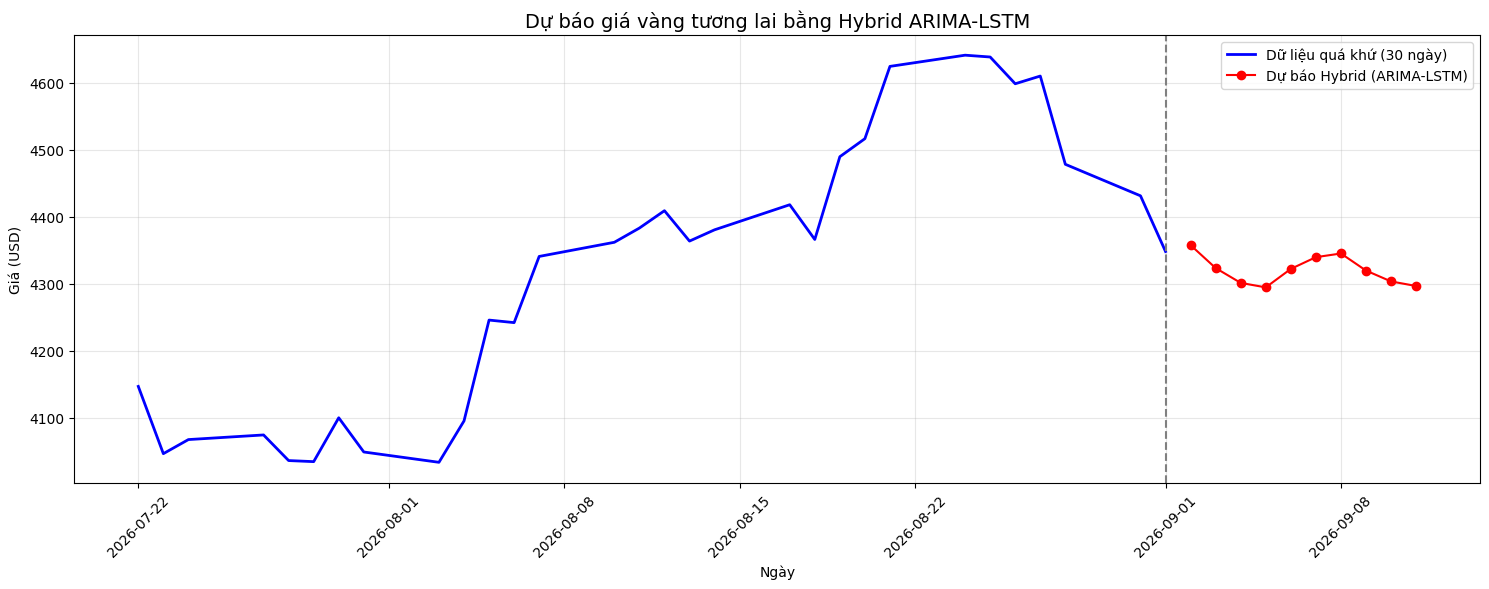

In [22]:
# 1. Lấy ngày tháng và giá trị thực tế từ biến 'df' đã có
history_window = 30
last_dates = df.index[-history_window:]
history_values = df['Close'].values[-history_window:]

# 2. Tạo chỉ mục ngày cho phần dự báo (Sử dụng forecast_steps = 10)
# 'forecast_series' đã có sẵn index là các ngày tiếp theo
forecast_dates = forecast_series.index

plt.figure(figsize=(15, 6))

# 3. Vẽ dữ liệu quá khứ (30 ngày gần nhất)
plt.plot(last_dates, history_values, label=f"Dữ liệu quá khứ ({history_window} ngày)", linewidth=2, color='blue')

# 4. Vẽ dữ liệu dự báo Hybrid
plt.plot(forecast_dates, final_forecast, 'ro-', label="Dự báo Hybrid (ARIMA-LSTM)")

# 5. Đường kẻ ngăn cách giữa quá khứ và dự báo
plt.axvline(x=last_dates[-1], color='grey', linestyle='--')

plt.title("Dự báo giá vàng tương lai bằng Hybrid ARIMA-LSTM", fontsize=14)
plt.xlabel("Ngày")
plt.ylabel("Giá (USD)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
import os
import pickle
from google.colab import drive
import tensorflow as tf

# 1. Kết nối Google Drive
try:
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive', force_remount=True)
except Exception as e:
    print(f"Lỗi kết nối Drive: {e}")

# 2. Thiết lập đường dẫn thư mục yêu cầu
target_dir = "/content/drive/MyDrive/CH LSTM_ARIMA"
os.makedirs(target_dir, exist_ok=True)

# 3. Lưu mô hình LSTM dưới định dạng .h5
if 'lstm_model' in locals():
    h5_path = os.path.join(target_dir, "hybrid_lstm_model.h5")
    lstm_model.save(h5_path)
    print(f"✅ Đã lưu file mô hình (.h5) tại: {h5_path}")
else:
    print("❌ Không tìm thấy biến 'lstm_model'.")

# 4. Lưu Scaler (scaler_res) - Rất quan trọng để tái sử dụng
if 'scaler_res' in locals():
    scaler_path = os.path.join(target_dir, "scaler_res.pkl")
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler_res, f)
    print(f"✅ Đã lưu file Scaler (.pkl) tại: {scaler_path}")
else:
    print("❌ Không tìm thấy biến 'scaler_res'.")

✅ Đã lưu file mô hình (.h5) tại: /content/drive/MyDrive/CH LSTM_ARIMA/hybrid_lstm_model.h5
✅ Đã lưu file Scaler (.pkl) tại: /content/drive/MyDrive/CH LSTM_ARIMA/scaler_res.pkl
